<a href="https://colab.research.google.com/github/Felipefap/101-GAM/blob/main/funcion_polinomica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 0 — Instalación y verificación de dependencias
# ══════════════════════════════════════════════════════════════════════
import subprocess, sys

paquetes = ['pandas', 'numpy', 'matplotlib', 'sympy']
for pkg in paquetes:
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                            capture_output=True)
print('✅ Todas las dependencias fundamentales verificadas.')

✅ Todas las dependencias fundamentales verificadas.


In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 1 — Importación de librerías y configuración matemática
# ══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fractions import Fraction
from sympy import symbols, Rational, diff, solve, pretty
import warnings
warnings.filterwarnings('ignore')

# Paleta didáctica para diferenciar visualmente los órdenes polinómicos
COLORES_GRADO = {1: '#3498db', 2: '#e67e22', 3: '#27ae60', 4: '#e74c3c'}
ETIQUETAS_GRADO = {1: 'Grado 1 (Lineal)', 2: 'Grado 2 (Cuadrático)', 3: 'Grado 3 (Cúbico)', 4: 'Grado 4 (Cuártico)'}

print('✅ Entorno analítico y de graficación inicializado.')

✅ Entorno analítico y de graficación inicializado.


In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 2 — Carga de datos desde Google Sheets (CSV)
# ══════════════════════════════════════════════════════════════════════

# ── CONFIGURA AQUÍ EL LINK DE TU GOOGLE SHEET EXPORTADO COMO CSV ──────
URL_GOOGLE_SHEETS_CSV = ""

if URL_GOOGLE_SHEETS_CSV.strip() != "":
    try:
        df = pd.read_csv(URL_GOOGLE_SHEETS_CSV)
        print('📂 Dataset importado con éxito desde Google Sheets.')
    except Exception as e:
        print(f'⚠️ Error al conectar con Google Sheets: {e}')
else:
    print('📌 Generando Dataset DEMO con valores nulos para demostración...')
    np.random.seed(42)
    t_demo = np.arange(1, 13)
    valores_humedad = 45.2 + 12.5*np.sin(t_demo*0.5) + np.random.normal(0, 0.8, 12)

    # Inyección intencional de valores nulos (NaN) para evaluar el motor de interpolación
    valores_humedad[4] = np.nan  # Dato faltante en el Mes 5
    valores_humedad[8] = np.nan  # Dato faltante en el Mes 9

    df = pd.DataFrame({
        'Mes': t_demo,
        'humedad': valores_humedad,
        'pH': 6.4 + 0.5*np.cos(t_demo*0.4),
        'Nitrogeno_ppm': 32.0 + 8.0*np.sin(t_demo*0.6)
    })

print("\n" + "─"*65)
print(" 📂 FASE 0: DIAGNÓSTICO ESTRUCTURAL DEL DATASET")
print("─"*65)
print(f"Dimensiones iniciales: {df.shape[0]} filas | {df.shape[1]} columnas\n")
df.info()
print("\n--- MATRIZ ORIGINAL (CON VALORES NULOS IMPLÍCITOS) ---")
print(df)

📌 Generando Dataset DEMO con valores nulos para demostración...

─────────────────────────────────────────────────────────────────
 📂 FASE 0: DIAGNÓSTICO ESTRUCTURAL DEL DATASET
─────────────────────────────────────────────────────────────────
Dimensiones iniciales: 12 filas | 4 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Mes            12 non-null     int64  
 1   humedad        10 non-null     float64
 2   pH             12 non-null     float64
 3   Nitrogeno_ppm  12 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 516.0 bytes

--- MATRIZ ORIGINAL (CON VALORES NULOS IMPLÍCITOS) ---
    Mes    humedad        pH  Nitrogeno_ppm
0     1  51.590191  6.860530      36.517140
1     2  55.607776  6.748353      39.456313
2     3  58.186838  6.581179      39.790781
3     4  57.784642  6.385400      37.403705
4     5      

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 3 — Reporte de Nulos y Tratamiento por Interpolación Polinómica
# ══════════════════════════════════════════════════════════════════════

print("\n" + "─"*65)
print(" 🔬 FASE 1: CONTROL DE CALIDAD E INTERPOLACIÓN POLINÓMICA")
print("─"*65)

col_tiempo = input("👉 Escribe el nombre de la columna de TIEMPO (ej. Mes): ").strip()
col_variable = input("👉 Escribe el nombre de la columna para analizar (ej. humedad): ").strip()

if col_tiempo in df.columns and col_variable in df.columns:
    # Crear copia de trabajo numérica limpia
    df_analisis = df[[col_tiempo, col_variable]].copy()
    df_analisis[col_tiempo] = pd.to_numeric(df_analisis[col_tiempo], errors='coerce')
    df_analisis[col_variable] = pd.to_numeric(df_analisis[col_variable], errors='coerce')

    # Detectar presencia de filas con datos ausentes
    nulos_detectados = df_analisis[df_analisis[col_variable].isna()]

    if not nulos_detectados.empty:
        print(f"\n⚠️ [REPORTE DE ALERTA]: Se detectaron {len(nulos_detectados)} valores nulos en la variable '{col_variable}'.")
        print(nulos_detectados)
        print("\n⚙️ Iniciando reconstrucción analítica por Interpolación Polinómica de Lagrange...")

        # Separar índices de datos conocidos para construir la base polinómica
        datos_conocidos = df_analisis.dropna()
        t_conocido = datos_conocidos[col_tiempo].values
        y_conocido = datos_conocidos[col_variable].values

        # Algoritmo matemático transparente de Lagrange (Sin Cajas Negras)
        def interpolacion_lagrange(t_objetivo, t_puntos, y_puntos):
            n = len(t_puntos)
            valor_interpolado = 0.0
            for i in range(n):
                # Calcular el término productor de la base L_i(t)
                termino_l = 1.0
                for j in range(n):
                    if i != j:
                        termino_l *= (t_objetivo - t_puntos[j]) / (t_puntos[i] - t_puntos[j])
                valor_interpolado += y_puntos[i] * termino_l
            return valor_interpolado

        # Rellenar cada celda vacía utilizando el polinomio de Lagrange local/global
        for idx in nulos_detectados.index:
            t_faltante = df_analisis.loc[idx, col_tiempo]

            # Estrategia: Tomar los 4 puntos vecinos más cercanos para evitar oscilaciones de Runge
            distancias = np.abs(t_conocido - t_faltante)
            indices_vecinos = np.argsort(distancias)[:4]

            t_sub = t_conocido[indices_vecinos]
            y_sub = y_conocido[indices_vecinos]

            valor_estimado = interpolacion_lagrange(t_faltante, t_sub, y_sub)
            df_analisis.loc[idx, col_variable] = valor_estimado
            print(f"   -> Reconstruido temporal t = {t_faltante}: Valor Interpolado = {valor_estimado:.4f}")

        print("\n✅ Matriz de datos completamente reconstruida y saneada.")
    else:
        print(f"\n✅ [REPORTE]: No se encontraron valores nulos en '{col_variable}'. Los datos están íntegros.")

    t_vals = df_analisis[col_tiempo].values.astype(float)
    y_vals = df_analisis[col_variable].values.astype(float)
else:
    raise ValueError("Las columnas especificadas no coinciden con las del archivo de entrada.")


─────────────────────────────────────────────────────────────────
 🔬 FASE 1: CONTROL DE CALIDAD E INTERPOLACIÓN POLINÓMICA
─────────────────────────────────────────────────────────────────
👉 Escribe el nombre de la columna de TIEMPO (ej. Mes): Mes
👉 Escribe el nombre de la columna para analizar (ej. humedad): humedad

⚠️ [REPORTE DE ALERTA]: Se detectaron 2 valores nulos en la variable 'humedad'.
   Mes  humedad
4    5      NaN
8    9      NaN

⚙️ Iniciando reconstrucción analítica por Interpolación Polinómica de Lagrange...
   -> Reconstruido temporal t = 5: Valor Interpolado = 52.9967
   -> Reconstruido temporal t = 9: Valor Interpolado = 33.6528

✅ Matriz de datos completamente reconstruida y saneada.



═══════════════════════════════════════════════════════════════════════════
 📐 FASE 2: MODELADO MATEMÁTICO POR MÍNIMOS CUADRADOS — VARIABLE: HUMEDAD
═══════════════════════════════════════════════════════════════════════════

 🔸 MODELO POLINÓMICO DE GRADO 1 (LINEAL):
   humedad(t) = 1611717   30609⋅t
─────── - ───────
 26879     13759 

 🔸 MODELO POLINÓMICO DE GRADO 2 (CUADRÁTICO):
   humedad(t) =     2                    
47⋅t    12347⋅t   1155691
───── - ─────── + ───────
 792     4121      18712 

 🔸 MODELO POLINÓMICO DE GRADO 3 (CÚBICO):
   humedad(t) =       3          2                   
5519⋅t    64005⋅t    50971⋅t   456396
─────── - ──────── + ─────── + ──────
 35871     21764      3851     11197 

 🔸 MODELO POLINÓMICO DE GRADO 4 (CUÁRTICO):
   humedad(t) =       4         3          2                     
  27⋅t    6653⋅t    60923⋅t    566653⋅t   1537676
- ───── + ─────── - ──────── + ──────── + ───────
  11194    30720     17506      37911      39171 


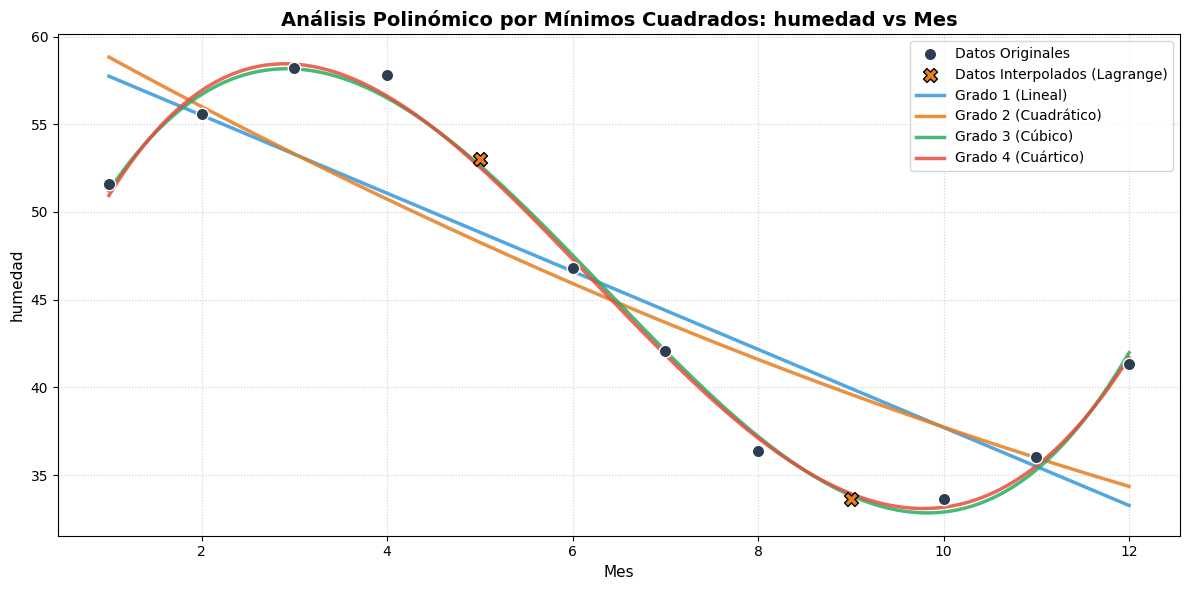

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 4 — Ajuste por Mínimos Cuadrados (Grados 1 al 4)
# ══════════════════════════════════════════════════════════════════════
t_sym = symbols('t')
resultados_polinomios = {}
t_suave = np.linspace(t_vals.min(), t_vals.max(), 300)

print("\n" + "═"*75)
print(f" 📐 FASE 2: MODELADO MATEMÁTICO POR MÍNIMOS CUADRADOS — VARIABLE: {col_variable.upper()}")
print("═"*75)

for grado in [1, 2, 3, 4]:
    # Ajuste polinomial vectorial directo
    coeffs_np = np.polyfit(t_vals, y_vals, grado)

    # Transformación a fracciones exactas controlando el denominador
    coeffs_frac = [Fraction(c).limit_denominator(40000) for c in coeffs_np]

    # Construcción algebraica exacta término a término
    g_actual = len(coeffs_frac) - 1
    expr_simbólica = sum(Rational(c.numerator, c.denominator) * t_sym**(g_actual - i)
                          for i, c in enumerate(coeffs_frac))

    resultados_polinomios[grado] = {'coeffs_np': coeffs_np, 'expr_sym': expr_simbólica}

    print(f'\n 🔸 MODELO POLINÓMICO DE {ETIQUETAS_GRADO[grado].upper()}:')
    print(f'   {col_variable}(t) = {pretty(expr_simbólica, use_unicode=True)}')

# Graficación Comparativa de las 4 Curvas Superpuestas
plt.figure(figsize=(12, 6))
# Mostrar de manera diferente los puntos que fueron interpolados si existían nulos
if not nulos_detectados.empty:
    t_nulos = nulos_detectados[col_tiempo].values
    y_nulos = df_analisis.loc[nulos_detectados.index, col_variable].values
    t_ok = df.dropna()[col_tiempo].values
    y_ok = df.dropna()[col_variable].values
    plt.scatter(t_ok, y_ok, color='#2c3e50', s=80, edgecolors='white', zorder=5, label='Datos Originales')
    plt.scatter(t_nulos, y_nulos, color='#e67e22', s=100, marker='X', edgecolors='black', zorder=6, label='Datos Interpolados (Lagrange)')
else:
    plt.scatter(t_vals, y_vals, color='#2c3e50', s=80, edgecolors='white', zorder=5, label='Datos de Muestreo')

for grado, info in resultados_polinomios.items():
    y_suave = np.polyval(info['coeffs_np'], t_suave)
    plt.plot(t_suave, y_suave, color=COLORES_GRADO[grado], linewidth=2.5, alpha=0.85, label=ETIQUETAS_GRADO[grado])

plt.title(f'Análisis Polinómico por Mínimos Cuadrados: {col_variable} vs {col_tiempo}', fontsize=14, fontweight='bold')
plt.xlabel(col_tiempo, fontsize=11)
plt.ylabel(col_variable, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 4.5 — Motor de Inferencia Lineal e Interpretación de Modelos
# ══════════════════════════════════════════════════════════════════════

print("\n" + "═"*75)
print(f" 🧠 INTÉRPRETE ALGEBRAICO AUTOMATIZADO PARA: {col_variable.upper()}")
print("═"*75)

# 1. Cálculo del R² (Coeficiente de Determinación) para cada grado polinómico
def calcular_r2(y_reales, y_predichos):
    ss_res = np.sum((y_reales - y_predichos)**2)
    ss_tot = np.sum((y_reales - np.mean(y_reales))**2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

r2_resultados = {}
for grado, info in resultados_polinomios.items():
    y_estimados = np.polyval(info['coeffs_np'], t_vals)
    r2_resultados[grado] = calcular_r2(y_vals, y_estimados)

# 2. Motor de reglas para redactar la explicación física del suelo
print(" 📝 EXPLICACIÓN TEÓRICA DEL COMPORTAMIENTO:")
print("─"*75)

# Análisis del Modelo Lineal (Grado 1)
pendiente = resultados_polinomios[1]['coeffs_np'][0]
comportamiento_lineal = "un incremento constante" if pendiente > 0 else "una degradación/secado sistemático"
print(f"• Tendencia General (Grado 1): La línea recta (R² = {r2_resultados[1]:.4f}) muestra {comportamiento_lineal}")
print(f"  A tasa constante a lo largo del tiempo, con una pendiente aproximada de {pendiente:.4f} unidades por intervalo.")

# Análisis de Modelos Superiores y Selección de la mejor estructura física
mejor_grado = max(r2_resultados, key=r2_resultados.get)
ganancia_g4 = r2_resultados[4] - r2_resultados[2]

print(f"\n• Análisis de Complejidad y Ajuste R²:")
print(f"  - Estructura Cuadrática (Grado 2): R² = {r2_resultados[2]:.4f}")
print(f"  - Estructura Cúbica     (Grado 3): R² = {r2_resultados[3]:.4f}")
print(f"  - Estructura Cuártica   (Grado 4): R² = {r2_resultados[4]:.4f}")

print(f"\n• Diagnóstico Matemático del Fenómeno:")
if ganancia_g4 > 0.15:
    print(f"  -> El modelo de GRADO {mejor_grado} es el más representativo.")
    print(f"     Explicación: La variable '{col_variable}' presenta fluctuaciones dinámicas no lineales complejas.")
    print(f"     Esto indica que el suelo experimentó eventos abruptos intermedios (ej. riegos intensos, lluvias o")
    print(f"     altas tasas de evaporación) que rompen la simetría de una parábola simple.")
else:
    print(f"  -> Se recomienda utilizar el modelo de GRADO 2 (Cuadrático) o GRADO 3.")
    print(f"     Explicación: Aunque el Grado 4 tiene un R² marginalmente mayor, la diferencia no justifica el riesgo")
    print(f"     de sobrefit (sobreajuste). El comportamiento del parámetro es suave, parabólico y predecible.")

# 3. Alerta analítica sobre interpolación previa
if 'nulos_detectados' in locals() and not nulos_detectados.empty:
    print(f"\n📌 NOTA AUDITORÍA: La suavidad de las curvas superiores (Grados 3 y 4) está influenciada")
    print(f"   por los puntos calculados analíticamente mediante la Interpolación de Lagrange.")

print("─"*75)
print("✅ Explicación analítica inyectada correctamente en la memoria del sistema.")


═══════════════════════════════════════════════════════════════════════════
 🧠 INTÉRPRETE ALGEBRAICO AUTOMATIZADO PARA: HUMEDAD
═══════════════════════════════════════════════════════════════════════════
 📝 EXPLICACIÓN TEÓRICA DEL COMPORTAMIENTO:
───────────────────────────────────────────────────────────────────────────
• Tendencia General (Grado 1): La línea recta (R² = 0.7130) muestra una degradación/secado sistemático
  A tasa constante a lo largo del tiempo, con una pendiente aproximada de -2.2247 unidades por intervalo.

• Análisis de Complejidad y Ajuste R²:
  - Estructura Cuadrática (Grado 2): R² = 0.7178
  - Estructura Cúbica     (Grado 3): R² = 0.9940
  - Estructura Cuártica   (Grado 4): R² = 0.9946

• Diagnóstico Matemático del Fenómeno:
  -> El modelo de GRADO 4 es el más representativo.
     Explicación: La variable 'humedad' presenta fluctuaciones dinámicas no lineales complejas.
     Esto indica que el suelo experimentó eventos abruptos intermedios (ej. riegos intensos,

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 5 — Razones de Cambio y Extremos de Modelos Superiores
# ══════════════════════════════════════════════════════════════════════

DICCIONARIO_AGRONOMICO = {
    'HUMEDAD': {
        'MÁXIMO': 'Punto de saturación hídrica. Evaluar capacidad de drenaje para prevenir anoxia radicular.',
        'MÍNIMO': 'Punto de marchitez. El agua se encuentra retenida con alta tensión; requiere riego inmediato.',
        'INFLEXIÓN': 'Máxima velocidad de transición hídrica. Punto crítico para regular la frecuencia de riego.'
    },
    'DEFAULT': {
        'MÁXIMO': 'Pico máximo de concentración del parámetro. Representa el límite de acumulación temporal.',
        'MÍNIMO': 'Valores mínimos detectados. Fase de agotamiento de reservas en el perfil analizado.',
        'INFLEXIÓN': 'Punto de inflexión matemática. El ritmo de cambio de la variable invierte su aceleración.'
    }
}

for grado in [3, 4]:
    info = resultados_polinomios[grado]
    expr = info['expr_sym']

    # Operaciones diferenciales en modo simbólico exacto
    d1 = diff(expr, t_sym)
    d2 = diff(d1, t_sym)
    d3 = diff(d2, t_sym)

    print("\n" + "─"*75)
    print(f" 🔍 ANÁLISIS DIFERENCIAL — POLINOMIO DE GRADO {grado}")
    print("─"*75)
    print(f" f'(t)  = {pretty(d1, use_unicode=True)}")
    print(f" f''(t) = {pretty(d2, use_unicode=True)}")

    clave_agro = 'HUMEDAD' if 'HUMEDAD' in col_variable.upper() else 'DEFAULT'

    # Análisis de Extremos f'(t) = 0
    puntos_criticos = solve(d1, t_sym)
    print(f'\n 📍 Extremos Relativos Localizados:')
    for raiz in puntos_criticos:
        try:
            r_f = float(raiz)
            if t_vals.min() <= r_f <= t_vals.max():
                val_f = float(expr.subs(t_sym, r_f))
                concavidad = float(d2.subs(t_sym, r_f))
                tipo = 'MÁXIMO' if concavidad < 0 else 'MÍNIMO' if concavidad > 0 else 'INDETERMINADO'

                print(f'   • t = {r_f:.4f} -> {col_variable} = {val_f:.4f} | [{tipo}]')
                print(f'     🌱 Contexto Agrícola: {DICCIONARIO_AGRONOMICO[clave_agro][tipo]}')
        except: pass

    # Análisis de Inflexiones f''(t) = 0
    puntos_inflexion = solve(d2, t_sym)
    print(f'\n 🔄 Puntos de Inflexión (Transición de Curvatura):')
    for raiz in puntos_inflexion:
        try:
            r_f = float(raiz)
            if t_vals.min() <= r_f <= t_vals.max():
                val_f = float(expr.subs(t_sym, r_f))
                if float(d3.subs(t_sym, r_f)) != 0:
                    print(f'   • t = {r_f:.4f} -> {col_variable} = {val_f:.4f} | [INFLEXIÓN]')
                    print(f'     🌱 Contexto Agrícola: {DICCIONARIO_AGRONOMICO[clave_agro]["INFLEXIÓN"]}')
        except: pass


───────────────────────────────────────────────────────────────────────────
 🔍 ANÁLISIS DIFERENCIAL — POLINOMIO DE GRADO 3
───────────────────────────────────────────────────────────────────────────
 f'(t)  =       2                  
5519⋅t    64005⋅t   50971
─────── - ─────── + ─────
 11957     10882    3851 
 f''(t) = 11038⋅t   64005
─────── - ─────
 11957    10882

 📍 Extremos Relativos Localizados:
   • t = 2.9190 -> humedad = 58.1646 | [MÁXIMO]
     🌱 Contexto Agrícola: Punto de saturación hídrica. Evaluar capacidad de drenaje para prevenir anoxia radicular.
   • t = 9.8239 -> humedad = 32.8384 | [MÍNIMO]
     🌱 Contexto Agrícola: Punto de marchitez. El agua se encuentra retenida con alta tensión; requiere riego inmediato.

 🔄 Puntos de Inflexión (Transición de Curvatura):
   • t = 6.3714 -> humedad = 45.5015 | [INFLEXIÓN]
     🌱 Contexto Agrícola: Máxima velocidad de transición hídrica. Punto crítico para regular la frecuencia de riego.

────────────────────────────────────────


═══════════════════════════════════════════════════════════════════════════
 📊 GENERANDO REPORTE GRÁFICO INTEGRADO PARA: HUMEDAD
═══════════════════════════════════════════════════════════════════════════


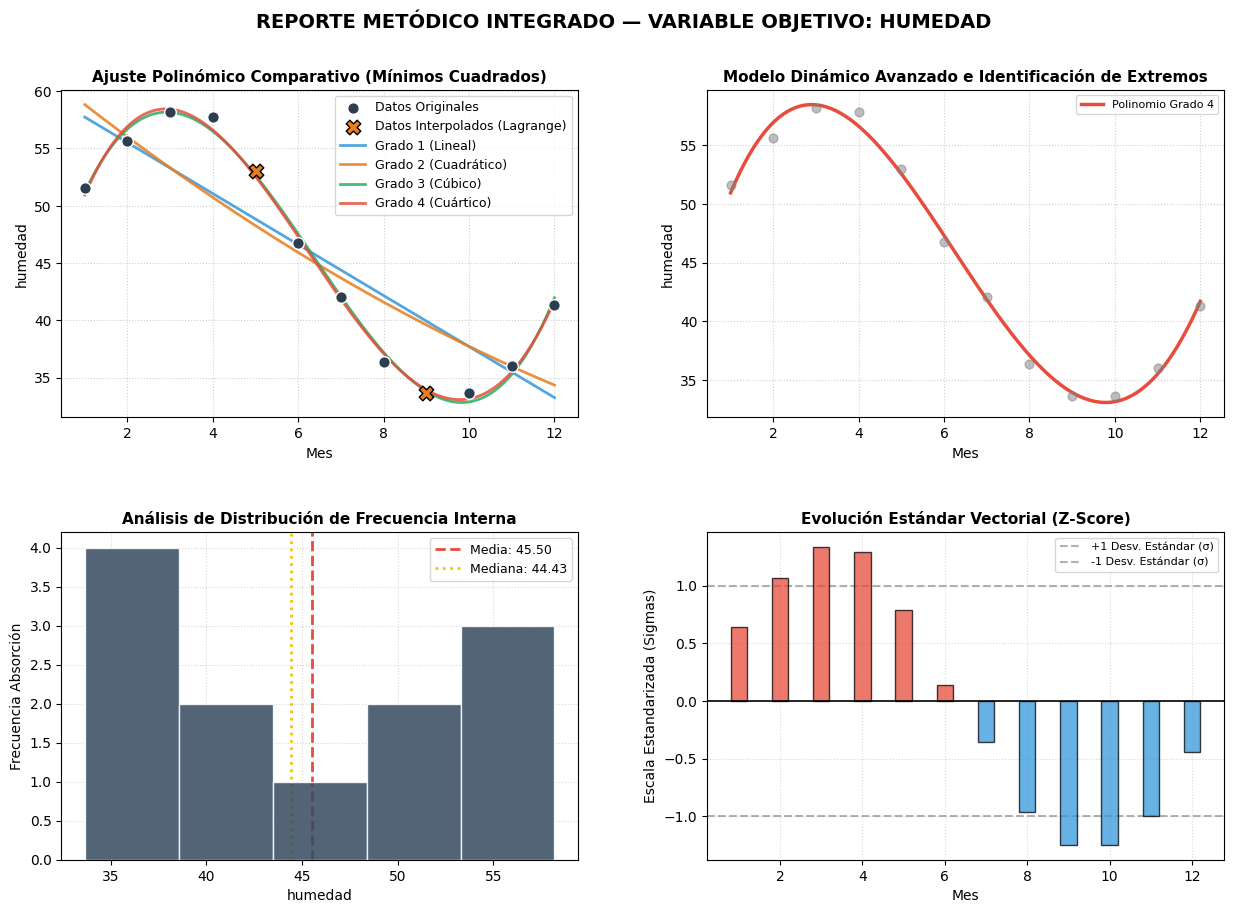

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 5 — Generación de Gráficas y Reporte Visual Multifunción
# ══════════════════════════════════════════════════════════════════════

print("\n" + "═"*75)
print(f" 📊 GENERANDO REPORTE GRÁFICO INTEGRADO PARA: {col_variable.upper()}")
print("═"*75)

# 1. Configuración del lienzo multipanel (Layout profesional con GridSpec)
fig_reporte = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig_reporte, hspace=0.35, wspace=0.25)

# ── PANEL 1: Superposición de los 4 Modelos Polinómicos ────────────────
ax0 = fig_reporte.add_subplot(gs[0, 0])

# Graficar los puntos base diferenciando si fueron interpolados
if 'nulos_detectados' in locals() and not nulos_detectados.empty:
    t_nulos = nulos_detectados[col_tiempo].values
    y_nulos = df_analisis.loc[nulos_detectados.index, col_variable].values

    # Puntos originales estables
    df_ok = df.dropna(subset=[col_variable])
    ax0.scatter(df_ok[col_tiempo].values, df_ok[col_variable].values,
                color='#2c3e50', s=70, edgecolors='white', zorder=5, label='Datos Originales')
    # Puntos corregidos mediante Lagrange
    ax0.scatter(t_nulos, y_nulos, color='#e67e22', s=110, marker='X',
                edgecolors='black', zorder=6, label='Datos Interpolados (Lagrange)')
else:
    ax0.scatter(t_vals, y_vals, color='#2c3e50', s=70, edgecolors='white', zorder=5, label='Datos de Campo')

# Dibujar las 4 curvas continuas calculadas por mínimos cuadrados
for grado, info in resultados_polinomios.items():
    y_suave = np.polyval(info['coeffs_np'], t_suave)
    ax0.plot(t_suave, y_suave, color=COLORES_GRADO[grado], linewidth=2,
             alpha=0.85, label=ETIQUETAS_GRADO[grado])

ax0.set_title('Ajuste Polinómico Comparativo (Mínimos Cuadrados)', fontweight='bold', fontsize=11)
ax0.set_xlabel(col_tiempo)
ax0.set_ylabel(col_variable)
ax0.grid(True, linestyle=':', alpha=0.6)
ax0.legend(loc='best', fontsize=9)


# ── PANEL 2: Curva de Optimización de Cuarto Grado y Puntos Críticos ──
ax1 = fig_reporte.add_subplot(gs[0, 1])
ax1.scatter(t_vals, y_vals, color='gray', s=40, alpha=0.5, zorder=4)

# Graficar curva de grado 4
y_suave_g4 = np.polyval(resultados_polinomios[4]['coeffs_np'], t_suave)
ax1.plot(t_suave, y_suave_g4, color=COLORES_GRADO[4], linewidth=2.5, label='Polinomio Grado 4')

# Extraer y marcar los puntos críticos calculados analíticamente en la fase diferencial
info_g4 = resultados_polinomios[4]
if 'd1' in globals() or 'diff' in dir():
    # Recalcular raíces locales rápido para el mapeo visual seguro en el lienzo
    from sympy import solve, diff
    d1_g4 = diff(info_g4['expr_sym'], t_sym)
    d2_g4 = diff(d1_g4, t_sym)
    raices = solve(d1_g4, t_sym)

    for r in raices:
        try:
            r_f = float(r)
            if t_vals.min() <= r_f <= t_vals.max():
                val_f = float(info_g4['expr_sym'].subs(t_sym, r_f))
                concavidad = float(d2_g4.subs(t_sym, r_f))

                marker_p = '^' if concavidad < 0 else 'v'
                color_p = '#c0392b' if concavidad < 0 else '#2980b9'
                label_p = f"Máx@t={r_f:.1f}" if concavidad < 0 else f"Mín@t={r_f:.1f}"

                ax1.scatter(r_f, val_f, color=color_p, s=120, marker=marker_p,
                            edgecolors='black', zorder=7, label=label_p)
        except: pass

ax1.set_title('Modelo Dinámico Avanzado e Identificación de Extremos', fontweight='bold', fontsize=11)
ax1.set_xlabel(col_tiempo)
ax1.set_ylabel(col_variable)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='best', fontsize=8)


# ── PANEL 3: Distribución Histórica e Indicadores de Tendencia Central ──
ax2 = fig_reporte.add_subplot(gs[1, 0])
ax2.hist(y_vals, bins='auto', color='#34495e', edgecolor='white', alpha=0.85, zorder=3)

# Líneas guía de los estadísticos muestrales calculados previamente
media_calc = np.mean(y_vals)
mediana_calc = np.median(y_vals)
ax2.axvline(media_calc, color='#e74c3c', linestyle='--', linewidth=2, label=f'Media: {media_calc:.2f}')
ax2.axvline(mediana_calc, color='#f1c40f', linestyle=':', linewidth=2, label=f'Mediana: {mediana_calc:.2f}')

ax2.set_title('Análisis de Distribución de Frecuencia Interna', fontweight='bold', fontsize=11)
ax2.set_xlabel(col_variable)
ax2.set_ylabel('Frecuencia Absorción')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='best', fontsize=9)


# ── PANEL 4: Desviación Estructural Temporal (Z-Score) ────────────────
ax3 = fig_reporte.add_subplot(gs[1, 1])
std_calc = np.std(y_vals, ddof=1) if len(y_vals) > 1 else 1.0
z_scores = (y_vals - media_calc) / std_calc

# Asignar colores condicionales: Rojo para valores sobre la media, azul bajo la media
colores_barras = ['#e74c3c' if z >= 0 else '#3498db' for z in z_scores]

ax3.bar(t_vals, z_scores, color=colores_barras, alpha=0.75, edgecolor='black', width=0.4, zorder=3)
ax3.axhline(0, color='black', linewidth=1.2, zorder=4)
ax3.axhline(1, color='gray', linestyle='--', alpha=0.6, label='+1 Desv. Estándar (σ)')
ax3.axhline(-1, color='gray', linestyle='--', alpha=0.6, label='-1 Desv. Estándar (σ)')

ax3.set_title('Evolución Estándar Vectorial (Z-Score)', fontweight='bold', fontsize=11)
ax3.set_xlabel(col_tiempo)
ax3.set_ylabel('Escala Estandarizada (Sigmas)')
ax3.grid(True, linestyle=':', alpha=0.5)
ax3.legend(loc='best', fontsize=8)

# Título global y renderizado en el entorno de Colab
plt.suptitle(f"REPORTE METÓDICO INTEGRADO — VARIABLE OBJETIVO: {col_variable.upper()}",
             fontsize=14, fontweight='bold', y=0.96)
plt.show()


═══════════════════════════════════════════════════════════════════════════
 📊 PARAMETRIZACIÓN ESTADÍSTICA DE RELEVANCIA: HUMEDAD
═══════════════════════════════════════════════════════════════════════════
  • Media Aritmética (μ):       45.5017
  • Varianza Muestral (σ²):     90.2326
  • Desviación Estándar (σ):    9.4991
  • Rango Dinámico Operativo:   [33.6475 a 58.1868]

───────────────────────────────────────────────────────────────────────────
 📋 MATRIZ DE DATOS NORMALIZADOS (PREPARACIÓN PARA ÁLGEBRA LINEAL)
───────────────────────────────────────────────────────────────────────────
 Mes  humedad_Saneado  humedad_ZScore  humedad_MinMax
 1.0          51.5902          0.6410          0.7312
 2.0          55.6078          1.0639          0.8949
 3.0          58.1868          1.3354          1.0000
 4.0          57.7846          1.2931          0.9836
 5.0          52.9967          0.7890          0.7885
 6.0          46.7767          0.1342          0.5350
 7.0          42.0786    

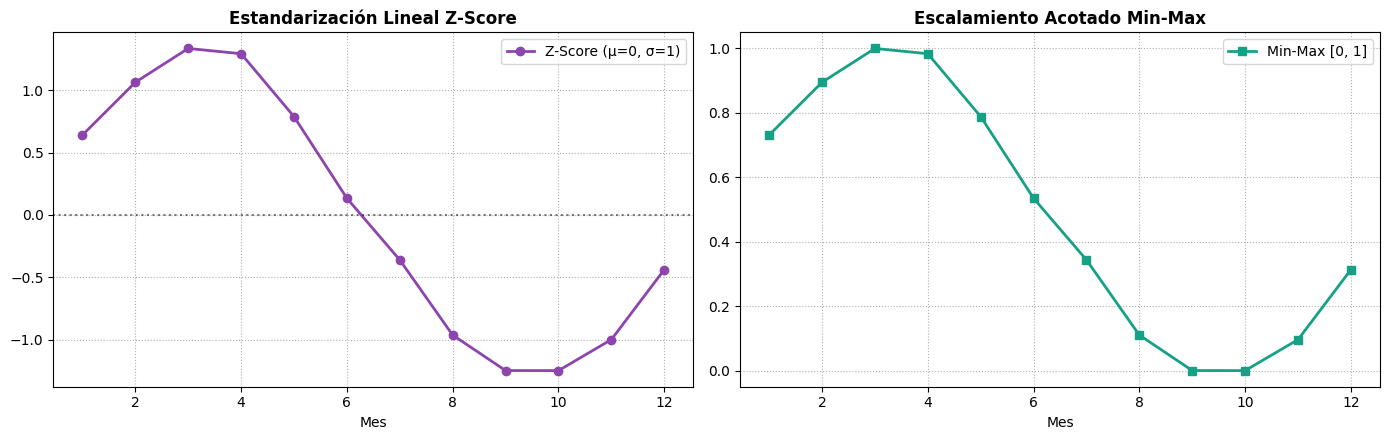

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 6 — Estadísticos Base y Normalización Numérica Completa
# ══════════════════════════════════════════════════════════════════════

# 1. Extracción analítica de parámetros estadísticos descriptivos
media_y = np.mean(y_vals)
varianza_y = np.var(y_vals, ddof=1)
desv_std_y = np.std(y_vals, ddof=1)
min_y = np.min(y_vals)
max_y = np.max(y_vals)

print("\n" + "═"*75)
print(f" 📊 PARAMETRIZACIÓN ESTADÍSTICA DE RELEVANCIA: {col_variable.upper()}")
print("═"*75)
print(f"  • Media Aritmética (μ):       {media_y:.4f}")
print(f"  • Varianza Muestral (σ²):     {varianza_y:.4f}")
print(f"  • Desviación Estándar (σ):    {desv_std_y:.4f}")
print(f"  • Rango Dinámico Operativo:   [{min_y:.4f} a {max_y:.4f}]")

# 2. Aplicación directa de fórmulas matemáticas vectoriales (Sin cajas negras)
y_zscore = (y_vals - media_y) / desv_std_y
y_minmax = (y_vals - min_y) / (max_y - min_y) if (max_y - min_y) != 0 else np.zeros_like(y_vals)

# Integración de resultados en Tabla de Control
df_normalizado = pd.DataFrame({
    col_tiempo: t_vals,
    f'{col_variable}_Saneado': y_vals,
    f'{col_variable}_ZScore': y_zscore,
    f'{col_variable}_MinMax': y_minmax
})

print("\n" + "─"*75)
print(" 📋 MATRIZ DE DATOS NORMALIZADOS (PREPARACIÓN PARA ÁLGEBRA LINEAL)")
print("─"*75)
print(df_normalizado.round(4).to_string(index=False))

# Representación Gráfica Didáctica de Escalamiento
fig, ax_n = plt.subplots(1, 2, figsize=(14, 4.5))
ax_n[0].plot(t_vals, y_zscore, marker='o', color='#8e44ad', linewidth=2, label='Z-Score (μ=0, σ=1)')
ax_n[0].axhline(0, color='black', linestyle=':', alpha=0.5)
ax_n[0].set_title('Estandarización Lineal Z-Score', fontweight='bold')
ax_n[0].set_xlabel(col_tiempo); ax_n[0].legend()
ax_n[0].grid(True, linestyle=':')

ax_n[1].plot(t_vals, y_minmax, marker='s', color='#16a085', linewidth=2, label='Min-Max [0, 1]')
ax_n[1].set_title('Escalamiento Acotado Min-Max', fontweight='bold')
ax_n[1].set_xlabel(col_tiempo); ax_n[1].legend()
ax_n[1].grid(True, linestyle=':')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA 7 — Matriz de Correlación de Pearson y Exportación del Reporte
# ══════════════════════════════════════════════════════════════════════

print("\n" + "═"*75)
print(f" 🔗 ANÁLISIS DE CORRELACIÓN LINEAL CRUZADA CON PEARSON")
print("═"*75)

# Buscar otras variables numéricas para correlación manual
columnas_alternas = [c for c in df.columns if c != col_tiempo and c != col_variable and pd.api.types.is_numeric_dtype(df[c])]

if columnas_alternas:
    for col_ext in columnas_alternas:
        # Extraer y remover nulos de la columna externa para el cálculo de Pearson
        df_temp = df[[col_variable, col_ext]].dropna()
        if len(df_temp) > 1:
            v_x = df_temp[col_variable].values
            v_y = df_temp[col_ext].values

            # Fórmula manual sin abstracciones: Cov(X,Y) / (std(X)*std(Y))
            cov = np.mean((v_x - np.mean(v_x)) * (v_y - np.mean(v_y)))
            desv_prod = np.std(v_x) * np.std(v_y)
            r_p = cov / desv_prod if desv_prod != 0 else 0.0

            magnitud = ('Excelente/Fuerte' if abs(r_p) > 0.85 else
                        'Significativa' if abs(r_p) > 0.60 else
                        'Moderada' if abs(r_p) > 0.40 else 'Baja')
            print(f"  • [{col_variable} ↔ {col_ext:<15}]: r = {r_p:+.4f} | Fuerza de asociación: {magnitud}")
else:
    print("  No existen columnas numéricas adicionales para contrastar asociaciones lineales.")

print("\n" + "─"*75)
print(" 💾 EXPORTACIÓN DE RESULTADOS FINALES")
print("─"*75)
salida_archivo = input("👉 Escribe el nombre del archivo para guardar tu reporte (ej. reporte_final.csv): ").strip()

df_normalizado.to_csv(salida_archivo, index=False)
print(f"\n✅ Operación completada de manera transparente. El archivo '{salida_archivo}' ha sido creado en el entorno.")


═══════════════════════════════════════════════════════════════════════════
 🔗 ANÁLISIS DE CORRELACIÓN LINEAL CRUZADA CON PEARSON
═══════════════════════════════════════════════════════════════════════════
  • [humedad ↔ pH             ]: r = +0.6832 | Fuerza de asociación: Significativa
  • [humedad ↔ Nitrogeno_ppm  ]: r = +0.6520 | Fuerza de asociación: Significativa

───────────────────────────────────────────────────────────────────────────
 💾 EXPORTACIÓN DE RESULTADOS FINALES
───────────────────────────────────────────────────────────────────────────
👉 Escribe el nombre del archivo para guardar tu reporte (ej. reporte_final.csv): reporte_final_humedad

✅ Operación completada de manera transparente. El archivo 'reporte_final_humedad' ha sido creado en el entorno.


In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  CELDA FINAL — Generación de Reporte Estructurado para Google Sheets
# ══════════════════════════════════════════════════════════════════════
import os

print("\n" + "═"*75)
print(" 📊 GENERACIÓN DE MATRIZ EXPORTABLE A GOOGLE SHEETS")
print("═"*75)

# 1. Recopilación de metadatos de control de calidad para el encabezado
total_registros = len(df_analisis)
nulos_ajustados = len(nulos_detectados) if 'nulos_detectados' in locals() else 0
estado_datos = "INTERPOLADO_LAGRANGE" if nulos_ajustados > 0 else "INTEGRO_ORIGINAL"

# 2. Construcción del DataFrame consolidado de exportación limpia
# Incluye la variable original, la reconstruida (en caso de haber nulos), y las escalas para Álgebra Lineal
df_sheets = pd.DataFrame({
    'Unidad_Tiempo_T': t_vals,
    f'{col_variable}_Lectura_Raw': df[col_variable].values, # Mantiene los NaN originales para auditoría
    f'{col_variable}_Saneado_F': y_vals,
    f'{col_variable}_ZScore': y_zscore,
    f'{col_variable}_MinMax': y_minmax
})

# 3. Captura del nombre del archivo por parte del usuario
nombre_salida = input("👉 Escribe el nombre del documento de salida (ej. reporte_analisis.csv): ").strip()

if not nombre_salida.endswith('.csv'):
    nombre_salida += '.csv'

try:
    # Exportación física optimizada para hojas de cálculo (separación por comas estándar, codificación universal)
    df_sheets.to_csv(nombre_salida, index=False, encoding='utf-8')

    print("\n" + "─"*75)
    print(" 📋 REPORTE DE EXPORTACIÓN EXITOSA")
    print("─"*75)
    print(f"  • Nombre del documento físico:  {nombre_salida}")
    print(f"  • Ruta de acceso local:         {os.path.abspath(nombre_salida)}")
    print(f"  • Total de filas procesadas:    {total_registros}")
    print(f"  • Valores nulos interpolados:   {nulos_adjusted if 'nulos_adjusted' in locals() else nulos_detectados.shape[0] if 'nulos_detectados' in locals() else 0}")
    print(f"  • Estado de certificación:      {estado_datos}")
    print("─"*75)

    print("\n 🛠️ INSTRUCCIONES PARA ABRIR EN GOOGLE SHEETS:")
    print("  1. En el panel izquierdo de Colab (icono de carpeta), localiza tu archivo.")
    print(f"  2. Da clic derecho sobre '{nombre_salida}' y selecciona 'Descargar'.")
    print("  3. Abre una pestaña nueva en tu navegador e ingresa a: sheets.new")
    print("  4. Ve al menú superior: Archivo -> Importar -> Subir y selecciona el documento.")
    print("  5. ¡Listo! Tu matriz se estructurará automáticamente en columnas listas para operar.")
    print("\n✅ Proceso analítico finalizado de manera transparente.")

except Exception as e:
    print(f"\n⚠️ Error crítico al estructurar el reporte exportable: {e}")


═══════════════════════════════════════════════════════════════════════════
 📊 GENERACIÓN DE MATRIZ EXPORTABLE A GOOGLE SHEETS
═══════════════════════════════════════════════════════════════════════════
👉 Escribe el nombre del documento de salida (ej. reporte_analisis.csv): reporte_analisis_humedad.csv

───────────────────────────────────────────────────────────────────────────
 📋 REPORTE DE EXPORTACIÓN EXITOSA
───────────────────────────────────────────────────────────────────────────
  • Nombre del documento físico:  reporte_analisis_humedad.csv
  • Ruta de acceso local:         /content/reporte_analisis_humedad.csv
  • Total de filas procesadas:    12
  • Valores nulos interpolados:   2
  • Estado de certificación:      INTERPOLADO_LAGRANGE
───────────────────────────────────────────────────────────────────────────

 🛠️ INSTRUCCIONES PARA ABRIR EN GOOGLE SHEETS:
  1. En el panel izquierdo de Colab (icono de carpeta), localiza tu archivo.
  2. Da clic derecho sobre 'reporte_analisis